# Hyperparameter Search Results — PLR `score_temp`

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

results = json.load(open("../results/temperature.json"))
df = pd.DataFrame(results).rename(columns={
    "env.plr.score_temp": "score_temp",
    "metric": "eval_iqm",
})
df = df.sort_values("score_temp").reset_index(drop=True)
df[["trial", "seed", "score_temp", "eval_iqm"]]

,trial,seed,score_temp,eval_iqm
0,7,815853,0.301917,4736.457031
1,2,175267,0.311569,4060.770508
2,13,422687,0.319824,3916.093262
3,1,269786,0.328681,4404.414062
4,14,8284,0.386998,4235.992676
5,10,89286,0.422959,4868.588379
6,12,481061,0.509798,4575.888184
7,11,863178,0.679023,4508.881836
8,5,729496,0.680537,3806.058838
9,4,970742,0.724645,4846.431152


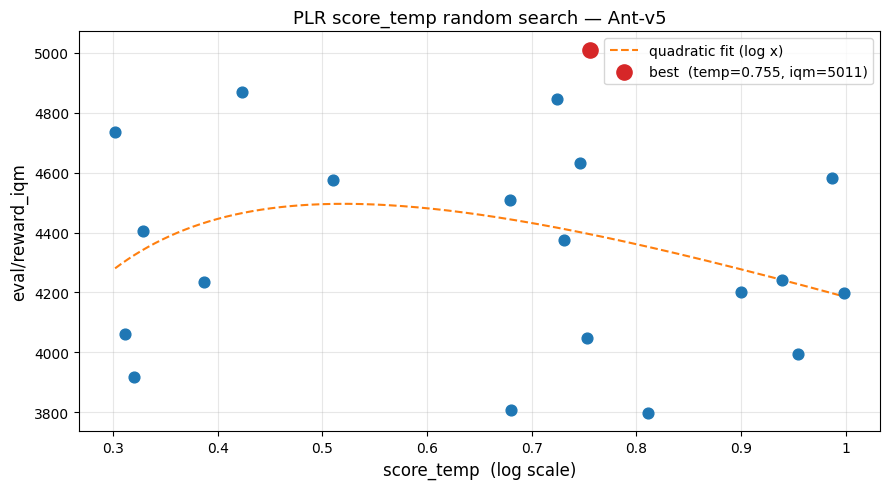


Best:  score_temp=0.7553  eval_iqm=5011.5  (trial 19, seed 685541)


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df["score_temp"], df["eval_iqm"], s=60, zorder=3)

# Trend line (log-space x since we sampled log-uniformly)
log_x = np.log(df["score_temp"])
coeffs = np.polyfit(log_x, df["eval_iqm"], deg=2)
x_smooth = np.exp(np.linspace(log_x.min(), log_x.max(), 300))
ax.plot(x_smooth, np.polyval(coeffs, np.log(x_smooth)),
        color="tab:orange", linewidth=1.5, linestyle="--", label="quadratic fit (log x)")

# Mark best trial
best = df.loc[df["eval_iqm"].idxmax()]
ax.scatter(best["score_temp"], best["eval_iqm"],
           s=120, color="tab:red", zorder=4, label=f"best  (temp={best['score_temp']:.3f}, iqm={best['eval_iqm']:.0f})")

# ax.set_xscale("log")
ax.set_xlabel("score_temp  (log scale)", fontsize=12)
ax.set_ylabel("eval/reward_iqm", fontsize=12)
ax.set_title("PLR score_temp random search — Ant-v5", fontsize=13)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3g"))
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest:  score_temp={best['score_temp']:.4f}  eval_iqm={best['eval_iqm']:.1f}  (trial {int(best['trial'])}, seed {int(best['seed'])})")

## Hyperparameter Search Results — PLR `replay_prob` × `staleness_coef`

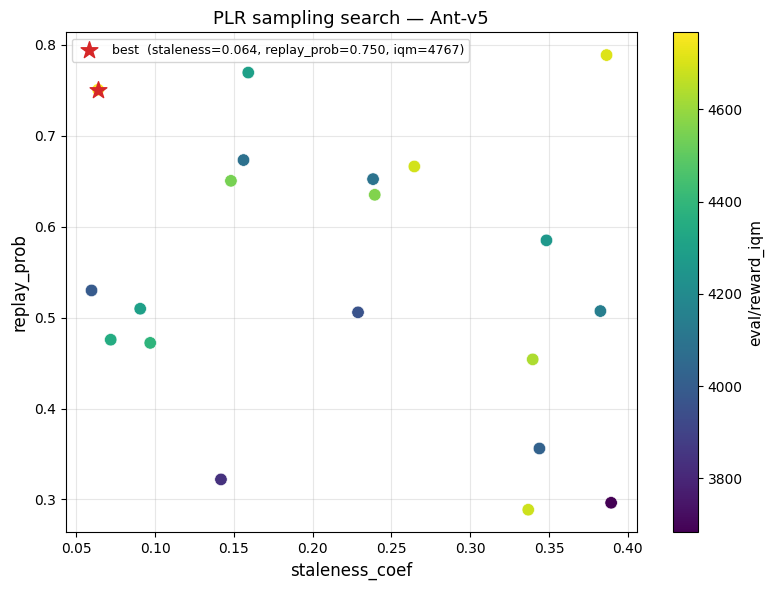


Best:  staleness_coef=0.0639  replay_prob=0.7504  eval_iqm=4767.3  (trial 14, seed 718527)


,trial,seed,staleness_coef,replay_prob,eval_iqm
0,14,718527,0.063858,0.750379,4767.313477
1,9,485190,0.386580,0.788442,4708.193848
2,13,623489,0.264551,0.666010,4693.764160
3,19,753030,0.336869,0.288753,4684.199707
4,2,256992,0.339696,0.453996,4632.819336
5,10,924931,0.239429,0.634874,4563.337891
6,8,498245,0.148143,0.650219,4544.520020
7,6,383311,0.096915,0.472099,4387.418457
8,15,528589,0.071822,0.475602,4351.228516
9,1,144159,0.159141,0.769190,4296.705078


In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

results = json.load(open("../results/plr_sampling.json"))
df = pd.DataFrame(results).rename(columns={
    "env.plr.replay_prob": "replay_prob",
    "env.plr.staleness_coef": "staleness_coef",
    "metric": "eval_iqm",
})

fig, ax = plt.subplots(figsize=(8, 6))

norm = mcolors.Normalize(vmin=df["eval_iqm"].min(), vmax=df["eval_iqm"].max())
cmap = cm.viridis
sc = ax.scatter(
    df["staleness_coef"], df["replay_prob"],
    c=df["eval_iqm"], cmap=cmap, norm=norm,
    s=80, zorder=3, edgecolors="white", linewidths=0.4,
)

# Mark best trial
best = df.loc[df["eval_iqm"].idxmax()]
ax.scatter(
    best["staleness_coef"], best["replay_prob"],
    s=160, color="tab:red", zorder=4, marker="*",
    label=f"best  (staleness={best['staleness_coef']:.3f}, replay_prob={best['replay_prob']:.3f}, iqm={best['eval_iqm']:.0f})",
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("eval/reward_iqm", fontsize=11)

ax.set_xlabel("staleness_coef", fontsize=12)
ax.set_ylabel("replay_prob", fontsize=12)
ax.set_title("PLR sampling search — Ant-v5", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest:  staleness_coef={best['staleness_coef']:.4f}  replay_prob={best['replay_prob']:.4f}  eval_iqm={best['eval_iqm']:.1f}  (trial {int(best['trial'])}, seed {int(best['seed'])})")
df[["trial", "seed", "staleness_coef", "replay_prob", "eval_iqm"]].sort_values("eval_iqm", ascending=False).reset_index(drop=True)

Quadratic model (2 inputs, 6 params, n=20)
  In-sample R²  : 0.235  ← inflated by overfitting
  LOO R²        : -0.952  ← honest generalization estimate

IQM range in data : 3683 – 4767  (spread 1084)
IQM std dev       : 311

Verdict: no reliable signal — LOO R² near zero means the model cannot predict
held-out points better than just using the mean. Noise dominates at n=20.


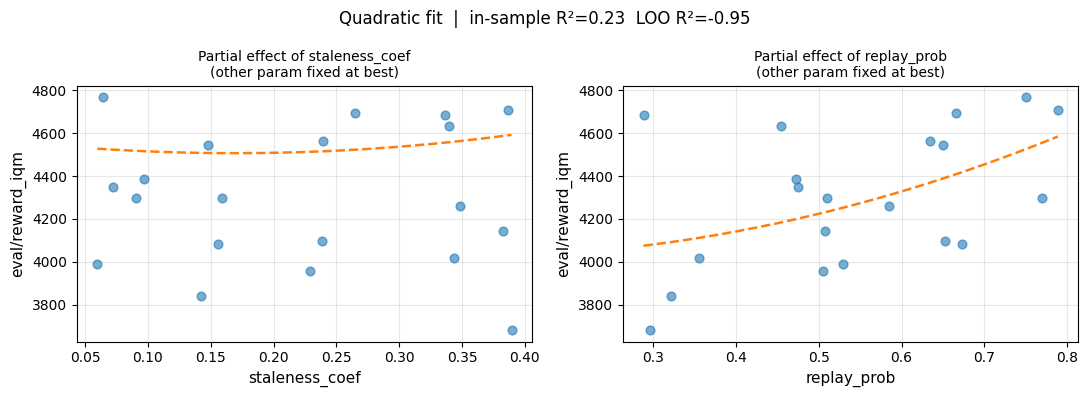

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
import numpy as np

X = df[["staleness_coef", "replay_prob"]].values
y = df["eval_iqm"].values

poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)

# In-sample R²
model = LinearRegression().fit(X_poly, y)
r2_train = r2_score(y, model.predict(X_poly))

# Leave-one-out R² — honest estimate with n=20
loo = LeaveOneOut()
y_loo = np.array([
    LinearRegression().fit(X_poly[train], y[train]).predict(X_poly[test])[0]
    for train, test in loo.split(X_poly)
])
r2_loo = r2_score(y, y_loo)

print(f"Quadratic model (2 inputs, 6 params, n=20)")
print(f"  In-sample R²  : {r2_train:.3f}  ← inflated by overfitting")
print(f"  LOO R²        : {r2_loo:.3f}  ← honest generalization estimate")
print()
print(f"IQM range in data : {y.min():.0f} – {y.max():.0f}  (spread {y.max()-y.min():.0f})")
print(f"IQM std dev       : {y.std():.0f}")
print()
if r2_loo < 0.1:
    print("Verdict: no reliable signal — LOO R² near zero means the model cannot predict")
    print("held-out points better than just using the mean. Noise dominates at n=20.")
elif r2_loo < 0.3:
    print("Verdict: weak signal at best. Don't read too much into the quadratic surface.")
else:
    print("Verdict: some signal present, but interpret with caution given small n.")

# Partial effects: vary one param while holding the other at its best value
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vary, fixed_name, fixed_val in [
    (axes[0], "staleness_coef", "replay_prob",   best["replay_prob"]),
    (axes[1], "replay_prob",   "staleness_coef", best["staleness_coef"]),
]:
    grid = np.linspace(df[vary].min(), df[vary].max(), 200)
    if vary == "staleness_coef":
        X_grid = np.column_stack([grid, np.full_like(grid, fixed_val)])
    else:
        X_grid = np.column_stack([np.full_like(grid, fixed_val), grid])
    y_pred = model.predict(poly.transform(X_grid))
    ax.plot(grid, y_pred, color="tab:orange", lw=1.8, linestyle="--")
    ax.scatter(df[vary], df["eval_iqm"], s=40, alpha=0.6, zorder=3)
    ax.set_xlabel(vary, fontsize=11)
    ax.set_ylabel("eval/reward_iqm", fontsize=11)
    ax.set_title(f"Partial effect of {vary}\n(other param fixed at best)", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Quadratic fit  |  in-sample R²={r2_train:.2f}  LOO R²={r2_loo:.2f}", fontsize=12)
plt.tight_layout()
plt.show()

## Hyperparameter Search Results — ACCEL `mutation_prob` × `mutation_sigma`

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

results = json.load(open("../results/accel_mutation.json"))
df_accel = pd.DataFrame(results).rename(columns={
    "env.plr.mutation_prob": "mutation_prob",
    "env.plr.mutation_sigma": "mutation_sigma",
    "metric": "eval_iqm",
})

fig, ax = plt.subplots(figsize=(8, 6))

norm = mcolors.Normalize(vmin=df_accel["eval_iqm"].min(), vmax=df_accel["eval_iqm"].max())
cmap = cm.viridis
sc = ax.scatter(
    df_accel["mutation_sigma"], df_accel["mutation_prob"],
    c=df_accel["eval_iqm"], cmap=cmap, norm=norm,
    s=80, zorder=3, edgecolors="white", linewidths=0.4,
)

best_accel = df_accel.loc[df_accel["eval_iqm"].idxmax()]
ax.scatter(
    best_accel["mutation_sigma"], best_accel["mutation_prob"],
    s=160, color="tab:red", zorder=4, marker="*",
    label=(
        f"best  (sigma={best_accel['mutation_sigma']:.3f}, "
        f"prob={best_accel['mutation_prob']:.3f}, "
        f"iqm={best_accel['eval_iqm']:.0f})"
    ),
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("eval/reward_iqm", fontsize=11)

ax.set_xscale("log")
ax.set_xlabel("mutation_sigma  (log scale)", fontsize=12)
ax.set_ylabel("mutation_prob", fontsize=12)
ax.set_title("ACCEL mutation search — Ant-v5", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest:  mutation_sigma={best_accel['mutation_sigma']:.4f}  mutation_prob={best_accel['mutation_prob']:.4f}  eval_iqm={best_accel['eval_iqm']:.1f}  (trial {int(best_accel['trial'])}, seed {int(best_accel['seed'])})")
df_accel[["trial", "seed", "mutation_sigma", "mutation_prob", "eval_iqm"]].sort_values("eval_iqm", ascending=False).reset_index(drop=True)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
import numpy as np

# Use log(mutation_sigma) as feature — sampled log-uniformly, so log-space is uniform
X = np.column_stack([df_accel["mutation_prob"].values, np.log(df_accel["mutation_sigma"].values)])
y = df_accel["eval_iqm"].values

poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)

model = LinearRegression().fit(X_poly, y)
r2_train = r2_score(y, model.predict(X_poly))

loo = LeaveOneOut()
y_loo = np.array([
    LinearRegression().fit(X_poly[train], y[train]).predict(X_poly[test])[0]
    for train, test in loo.split(X_poly)
])
r2_loo = r2_score(y, y_loo)

print(f"Quadratic model (mutation_prob, log(mutation_sigma) — n={len(y)})")
print(f"  In-sample R²  : {r2_train:.3f}")
print(f"  LOO R²        : {r2_loo:.3f}")
print()
print(f"IQM range : {y.min():.0f} – {y.max():.0f}  (spread {y.max()-y.min():.0f})")
print(f"IQM std   : {y.std():.0f}")
print()
if r2_loo < 0.1:
    print("Verdict: no reliable signal — noise dominates, pick best trial with caution.")
elif r2_loo < 0.3:
    print("Verdict: weak signal. Treat best trial as a soft recommendation.")
else:
    print("Verdict: some signal present — surface is informative.")

# Partial-effect plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vary, fixed_name, fixed_val in [
    (axes[0], "mutation_prob",  "log_mutation_sigma", np.log(best_accel["mutation_sigma"])),
    (axes[1], "log_mutation_sigma", "mutation_prob",  best_accel["mutation_prob"]),
]:
    grid = np.linspace(X[:, 0 if vary == "mutation_prob" else 1].min(),
                       X[:, 0 if vary == "mutation_prob" else 1].max(), 200)
    if vary == "mutation_prob":
        X_grid = np.column_stack([grid, np.full_like(grid, fixed_val)])
        scatter_x = df_accel["mutation_prob"].values
        xlabel = "mutation_prob"
    else:
        X_grid = np.column_stack([np.full_like(grid, fixed_val), grid])
        scatter_x = np.log(df_accel["mutation_sigma"].values)
        xlabel = "log(mutation_sigma)"

    y_pred = model.predict(poly.transform(X_grid))
    ax.plot(grid, y_pred, color="tab:orange", lw=1.8, linestyle="--")
    ax.scatter(scatter_x, y, s=40, alpha=0.6, zorder=3)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("eval/reward_iqm", fontsize=11)
    ax.set_title(f"Partial effect of {xlabel}\n(other param fixed at best)", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Quadratic fit  |  in-sample R²={r2_train:.2f}  LOO R²={r2_loo:.2f}", fontsize=12)
plt.tight_layout()
plt.show()